In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

In [2]:
digits_dataset = tf.keras.datasets.mnist

In [3]:
((x_train, y_train), (x_test, y_test)) = digits_dataset.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

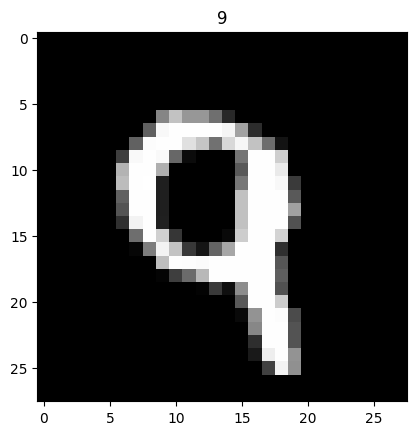

In [6]:
random_index = np.random.randint(0, 60_000)

plt.imshow(x_train[random_index], cmap="gray");
plt.title(y_train[random_index]);

In [7]:
x_only_seven = x_train[y_train == 7]
x_only_seven.shape

(6265, 28, 28)

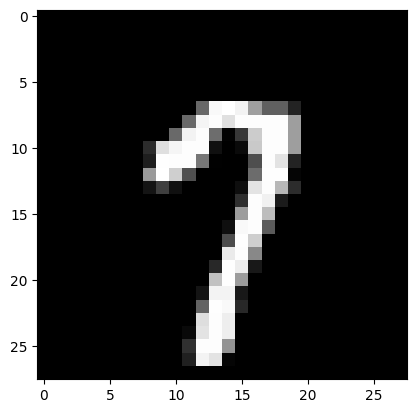

In [14]:
random_index = np.random.randint(0, 6265)
plt.imshow(x_only_seven[random_index], cmap="gray");

# 1. Crearea unui GAN (GENERATIVE ADVERSARIAL NETWORKS)

In [15]:
generator = tf.keras.models.Sequential([

])
discriminator =  tf.keras.models.Sequential([

])
GAN =  tf.keras.models.Sequential([generator, discriminator])
GAN.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# 2. Crearea discriminatorul (clasic CNN)

In [17]:
generator = tf.keras.models.Sequential([

])
discriminator =  tf.keras.models.Sequential([
          tf.keras.layers.Flatten(),

          tf.keras.layers.Dense(units=200, activation="relu"),

          tf.keras.layers.Dense(units=100, activation="relu"),

          ## OUTPUT -> discriminatorul spune daca imaginea generata este buna sau nu
          tf.keras.layers.Dense(units=1, activation="sigmoid")
])
discriminator.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])


GAN =  tf.keras.models.Sequential([generator, discriminator])
GAN.summary()


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_6 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# 3. Crearea generatorului in oglinda cu discriminatorul

In [20]:
generator = tf.keras.models.Sequential([

        tf.keras.layers.Dense(units=100, activation="relu"),

        tf.keras.layers.Dense(units=200, activation="relu"),

        tf.keras.layers.Dense(units=28 * 28, activation="relu"),

        tf.keras.layers.Reshape(target_shape=(28, 28)),

])
discriminator =  tf.keras.models.Sequential([
          tf.keras.layers.Flatten(),

          tf.keras.layers.Dense(units=200, activation="relu"),

          tf.keras.layers.Dense(units=100, activation="relu"),

          ## OUTPUT -> discriminatorul spune daca imaginea generata este buna sau nu
          tf.keras.layers.Dense(units=1, activation="sigmoid")
])
discriminator.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])


discriminator.trainable = False

GAN =  tf.keras.models.Sequential([generator, discriminator])

GAN.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

GAN.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_15 (Sequential)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_16 (Sequential)      │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
x_only_seven.shape

(6265, 28, 28)

In [22]:
tf.data.Dataset.from_tensor_slices(x_only_seven)

<_TensorSliceDataset element_spec=TensorSpec(shape=(28, 28), dtype=tf.uint8, name=None)>

In [23]:
slice_dataset = tf.data.Dataset.from_tensor_slices(x_only_seven)
slice_dataset, type(slice_dataset)

(<_TensorSliceDataset element_spec=TensorSpec(shape=(28, 28), dtype=tf.uint8, name=None)>,
 tensorflow.python.data.ops.from_tensor_slices_op._TensorSliceDataset)

In [24]:
batch_size = 32
new_slice_dataset = slice_dataset.batch(batch_size, drop_remainder=True).prefetch(1)
new_slice_dataset


<_PrefetchDataset element_spec=TensorSpec(shape=(32, 28, 28), dtype=tf.uint8, name=None)>

In [25]:
noise = tf.random.normal(shape=(batch_size, 100))
noise

<tf.Tensor: shape=(32, 100), dtype=float32, numpy=
array([[ 2.4985062e-01, -4.0156657e-01, -8.7892848e-01, ...,
        -3.5336581e-01,  8.2518911e-01,  3.4779452e-02],
       [-2.7072412e-01,  5.7554382e-01, -1.6851687e-01, ...,
        -8.2850605e-01,  9.6510613e-01,  8.1096953e-01],
       [ 1.6838163e-02, -2.6342860e-01, -1.1600986e-01, ...,
         1.4058866e-02, -3.6848632e-01, -4.9646378e-01],
       ...,
       [-1.9560682e+00, -7.2889417e-01,  1.3494886e+00, ...,
         3.5011593e-01, -4.3640348e-01,  1.4435161e+00],
       [-3.3436975e-01,  1.9956148e+00, -5.4034919e-01, ...,
         5.2834865e-02,  1.2346083e+00, -2.3266273e-03],
       [-2.2771022e+00,  7.1232639e-02, -7.4096018e-01, ...,
        -3.1727669e+00, -8.4436023e-01,  3.2911834e-01]], dtype=float32)>

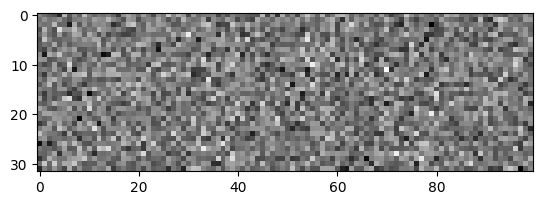

In [27]:
plt.imshow(noise, cmap="gray")

In [33]:
EPOCHS = 20

for epoch in range(EPOCHS):
    print(f"Suntem in epoca {epoch}")
    for real_bach_of_data in new_slice_dataset:


      noise = tf.random.normal(shape=(batch_size, 100))

      fake_images = generator(noise)
      real_images = tf.cast(real_bach_of_data, dtype=tf.float32)

      fake_and_real_images = tf.concat([fake_images, real_images], axis=0)


      real_labels = tf.ones(shape=(batch_size, 1))
      fake_labels = tf.zeros(shape=(batch_size, 1))

      real_and_fake_labels = tf.concat([fake_labels, real_labels], axis=0)


      ## Pas 1 - antrenare discriminator

      discriminator.trainable = True

      discriminator.train_on_batch(fake_and_real_images, real_and_fake_labels)

      discriminator.trainable = False



      ## Pas 2 - antrenare GAN

      GAN.train_on_batch(noise, tf.ones(shape=(batch_size, 1)))



Suntem in epoca 0
Suntem in epoca 1
Suntem in epoca 2
Suntem in epoca 3
Suntem in epoca 4
Suntem in epoca 5
Suntem in epoca 6
Suntem in epoca 7
Suntem in epoca 8
Suntem in epoca 9
Suntem in epoca 10
Suntem in epoca 11
Suntem in epoca 12
Suntem in epoca 13
Suntem in epoca 14
Suntem in epoca 15
Suntem in epoca 16
Suntem in epoca 17
Suntem in epoca 18
Suntem in epoca 19


In [34]:
noise = tf.random.normal(shape=(batch_size, 100))
generated_fake_images = generator(noise)

generated_fake_images.shape


TensorShape([32, 28, 28])

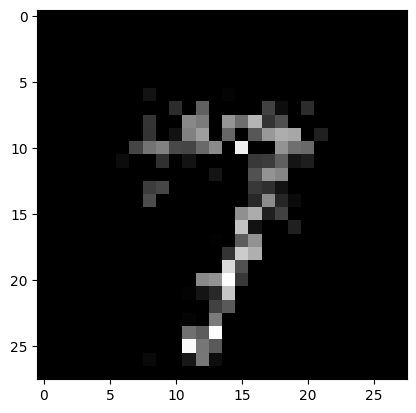

In [35]:
plt.imshow(generated_fake_images[2], cmap="gray")